In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)

df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
etiquetas = {
    0: "Cabernet",
    1: "Merlot",
    2: "Pinot Noir"
}

df["tipo_vino"] = df["target"].map(etiquetas)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,tipo_vino
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cabernet
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cabernet
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cabernet
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cabernet
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cabernet


In [4]:
df.shape

(178, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [7]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [8]:
df["tipo_vino"].value_counts()

,count
tipo_vino,
Merlot,71
Cabernet,59
Pinot Noir,48


In [9]:
X = df[[
    "alcohol",
    "malic_acid",
    "color_intensity",
    "proline"
]]

y = df["tipo_vino"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (178, 4)
Dimensiones de y: (178,)


In [10]:
X.head()

,alcohol,malic_acid,color_intensity,proline
0,14.23,1.71,5.64,1065.0
1,13.20,1.78,4.38,1050.0
2,13.16,2.36,5.68,1185.0
3,14.37,1.95,7.80,1480.0
4,13.24,2.59,4.32,735.0


In [11]:
y.head()

,tipo_vino
0,Cabernet
1,Cabernet
2,Cabernet
3,Cabernet
4,Cabernet


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 4)
X_test: (36, 4)
y_train: (142,)
y_test: (36,)


In [13]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

modelo

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])

In [14]:
modelo.fit(X_train, y_train)

print("Clases aprendidas por el modelo:")
print(modelo.classes_)

Clases aprendidas por el modelo:
['Cabernet' 'Merlot' 'Pinot Noir']


In [15]:
modelo.classes_

array(['Cabernet', 'Merlot', 'Pinot Noir'], dtype=object)

In [16]:
y_pred = modelo.predict(X_test)

resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

resultados.head()

,Real,Predicho
0,Cabernet,Cabernet
1,Pinot Noir,Merlot
2,Cabernet,Cabernet
3,Merlot,Pinot Noir
4,Merlot,Merlot


In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9166666666666666
Precision: 0.9172839506172841
Recall: 0.9166666666666666
F1-score: 0.9159104658197218


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Cabernet       1.00      1.00      1.00        12
      Merlot       0.87      0.93      0.90        14
  Pinot Noir       0.89      0.80      0.84        10

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



In [19]:
average="weighted"

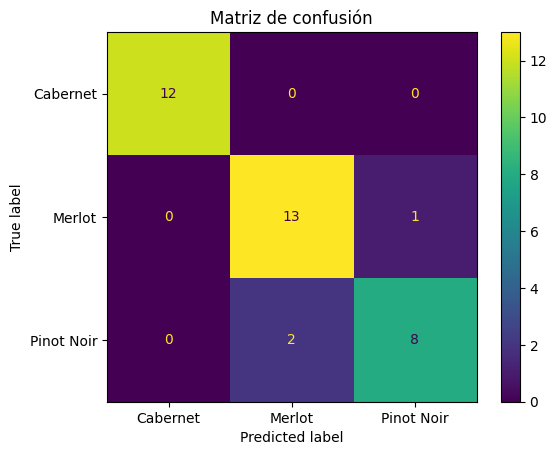

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Cabernet", "Merlot", "Pinot Noir"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cabernet", "Merlot", "Pinot Noir"]
)

disp.plot()
plt.title("Matriz de confusión")
plt.show()

In [21]:
nuevo_vino = pd.DataFrame({
    "alcohol": [13.5],
    "malic_acid": [1.8],
    "color_intensity": [5.2],
    "proline": [1000]
})

prediccion_nueva = modelo.predict(nuevo_vino)

print("Tipo de vino predicho:", prediccion_nueva[0])

Tipo de vino predicho: Cabernet


In [23]:
joblib.dump(modelo, "modelo_wine.pkl")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [24]:
modelo_recuperado = joblib.load("modelo_wine.pkl")

prediccion_recuperada = modelo_recuperado.predict(nuevo_vino)

print("Predicción anterior:", prediccion_nueva[0])
print("Predicción recuperada:", prediccion_recuperada[0])

Predicción anterior: Cabernet
Predicción recuperada: Cabernet
